
# Sequence Classification with RNN, LSTM, and GRU: A Comparative Study

---

### Abstract

Recurrent architectures — the vanilla **RNN**, the **LSTM** (Long Short-Term Memory), and the **GRU**
(Gated Recurrent Unit) — are the classical building blocks for modeling sequential data. This notebook
implements all three architectures from scratch using PyTorch's `nn.RNN`, `nn.LSTM`, and `nn.GRU` modules,
trains them on an identical **binary sequence classification task**, and rigorously compares them using
accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, training dynamics, computational
efficiency, and — most importantly — **robustness to long-range dependencies**, which is the central
theoretical reason LSTM/GRU were invented (to combat the vanishing-gradient problem of vanilla RNNs).

### What makes this study rigorous rather than a toy demo

1. A **synthetic but controlled** dataset is used so that the *true* signal (label-generating rule) is
   known exactly. This lets us design a task with a **long-range dependency** (important tokens are placed
   near the start of variable-length sequences, and the sequence is classified from the *final* hidden
   state), which is precisely the regime in which vanilla RNNs are expected to fail relative to gated
   architectures.
2. Sequences are handled with **padding + `pack_padded_sequence`**, so that padding tokens never
   contaminate the hidden state used for classification — a common correctness bug in naive
   implementations.
3. All three models are given the **same embedding size, hidden size, optimizer, learning rate, batch
   size, and number of epochs**, so that differences in performance can be attributed to the recurrent
   cell architecture rather than to hyperparameter advantages.
4. Evaluation goes beyond accuracy: we report a **full metric suite**, **training curves**, **confusion
   matrices**, **ROC curves**, an **accuracy-vs-sequence-length stress test**, and a **compute-efficiency**
   comparison (parameters, training time, inference time).

---

### Table of Contents
1. [Setup & Reproducibility](#1)
2. [The Task & Synthetic Dataset](#2)
3. [Data Pipeline (Dataset / DataLoader / Padding)](#3)
4. [Model Architectures (RNN / LSTM / GRU)](#4)
5. [Training Loop & Experiment Runner](#5)
6. [Training Dynamics: Loss & Accuracy Curves](#6)
7. [Test-Set Evaluation: Full Metric Suite](#7)
8. [Confusion Matrices & ROC Curves](#8)
9. [Stress Test: Accuracy vs. Sequence Length (Long-Range Dependencies)](#9)
10. [Computational Efficiency](#10)
11. [Overall Comparison & Summary](#11)
12. [Conclusions & Discussion](#12)


## 1. Setup & Reproducibility <a id='1'></a>

In [1]:

import time
import math
import random
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)

# ----- Reproducibility -----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----- Plot styling -----
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
PALETTE = {"RNN": "#e0554e", "LSTM": "#3d6dbf", "GRU": "#2ea86e"}
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

print(f"PyTorch version : {torch.__version__}")
print(f"Device in use   : {DEVICE}")
print(f"Random seed     : {SEED}")


PyTorch version : 2.11.0+cpu
Device in use   : cpu
Random seed     : 42



## 2. The Task & Synthetic Dataset <a id='2'></a>

**Task definition — "Early-Signal Sentiment":** each sample is a variable-length sequence of token IDs.
Most tokens are semantically **neutral filler**. Embedded near the **start** of the sequence (within the
first 30% of positions) are exactly **3 signal tokens**, each of which is either *positive* or *negative*.
The label is the **majority class of the 3 signal tokens** (ties are impossible since 3 is odd):

$$
y = \begin{cases} 1 \ (\text{positive}) & \text{if } \#\text{positive signals} > \#\text{negative signals} \\ 0 \ (\text{negative}) & \text{otherwise} \end{cases}
$$

Sequence lengths are drawn uniformly from **[15, 45]**. Because classification is performed from the
**final** hidden state of the recurrent network, the model must **carry information from near the
beginning of the sequence all the way to the end**, across a long stretch of uninformative filler tokens.
This is a controlled, synthetic stand-in for the classic long-range dependency problems (e.g. sentiment
carried by an early phrase in a long review) that motivated the invention of LSTM (Hochreiter &
Schmidhuber, 1997) and GRU (Cho et al., 2014) as remedies to the vanishing-gradient problem of vanilla RNNs.

Vocabulary layout: `0` = PAD, `1-4` = positive-signal tokens, `5-8` = negative-signal tokens,
`9-58` = neutral filler tokens (50 filler symbols). Vocabulary size = 59.


In [2]:

PAD_IDX = 0
POS_TOKENS = (1, 4)      # inclusive low, exclusive-high handled via randint below
NEG_TOKENS = (5, 8)
FILLER_TOKENS = (9, 58)
VOCAB_SIZE = 59

def generate_dataset(n_samples, min_len=15, max_len=45, seed=0):
    rng = np.random.default_rng(seed)
    sequences, labels, lengths = [], [], []
    for _ in range(n_samples):
        length = int(rng.integers(min_len, max_len + 1))
        seq = rng.integers(FILLER_TOKENS[0], FILLER_TOKENS[1] + 1, size=length)
        early_region = max(3, int(length * 0.30))
        positions = rng.choice(early_region, size=3, replace=False)

        pos_count = neg_count = 0
        for p in positions:
            if rng.random() < 0.5:
                seq[p] = rng.integers(POS_TOKENS[0], POS_TOKENS[1] + 1)
                pos_count += 1
            else:
                seq[p] = rng.integers(NEG_TOKENS[0], NEG_TOKENS[1] + 1)
                neg_count += 1

        label = 1 if pos_count > neg_count else 0
        sequences.append(seq.tolist())
        labels.append(label)
        lengths.append(length)
    return sequences, labels, lengths

N_TOTAL = 4000
sequences, labels, lengths = generate_dataset(N_TOTAL, seed=SEED)

print(f"Generated {N_TOTAL} sequences")
print(f"Length range   : [{min(lengths)}, {max(lengths)}]  (mean {np.mean(lengths):.1f})")
print(f"Class balance  : {np.bincount(labels)} (0=negative, 1=positive)")
print(f"\nExample sequence (label={labels[0]}):\n{sequences[0]}")


Generated 4000 sequences
Length range   : [15, 45]  (mean 29.8)
Class balance  : [1975 2025] (0=negative, 1=positive)

Example sequence (label=0):
[47, 2, 7, 30, 8, 13, 43, 19, 13, 35, 57, 45, 47, 44, 48, 34, 15]


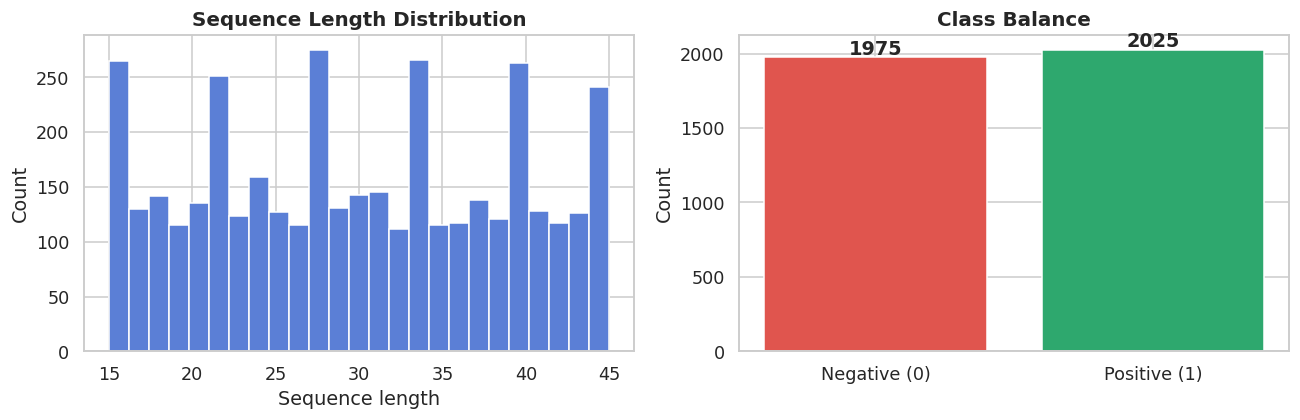

In [3]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lengths, bins=25, color="#5b7fd6", edgecolor="white")
axes[0].set_title("Sequence Length Distribution")
axes[0].set_xlabel("Sequence length")
axes[0].set_ylabel("Count")

class_counts = np.bincount(labels)
axes[1].bar(["Negative (0)", "Positive (1)"], class_counts,
            color=["#e0554e", "#2ea86e"], edgecolor="white")
axes[1].set_title("Class Balance")
axes[1].set_ylabel("Count")
for i, v in enumerate(class_counts):
    axes[1].text(i, v + 20, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()



## 3. Data Pipeline (Dataset / DataLoader / Padding) <a id='3'></a>

We split the data **70% / 15% / 15%** into train / validation / test sets, then wrap it in a custom
`torch.utils.data.Dataset`. A `collate_fn` pads each batch to the length of its longest sequence and
returns the **true (unpadded) lengths**, which are later fed into `pack_padded_sequence` so that the
recurrent layers never process — or get "polluted" by — pad tokens when extracting the final hidden state.


In [4]:

class SequenceDataset(Dataset):
    def __init__(self, sequences, labels, lengths):
        self.sequences = sequences
        self.labels = labels
        self.lengths = lengths

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return (torch.tensor(self.sequences[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.float32),
                self.lengths[idx])


def collate_fn(batch):
    seqs, labs, lens = zip(*batch)
    lens = torch.tensor(lens, dtype=torch.long)
    padded = nn.utils.rnn.pad_sequence(seqs, batch_first=True, padding_value=PAD_IDX)
    labs = torch.stack(labs)
    return padded, labs, lens


# ----- Split: 70 / 15 / 15 -----
idx = np.arange(N_TOTAL)
rng = np.random.default_rng(SEED)
rng.shuffle(idx)

n_train = int(0.70 * N_TOTAL)
n_val = int(0.15 * N_TOTAL)
train_idx = idx[:n_train]
val_idx = idx[n_train:n_train + n_val]
test_idx = idx[n_train + n_val:]

def subset(indices):
    return ([sequences[i] for i in indices],
             [labels[i] for i in indices],
             [lengths[i] for i in indices])

train_ds = SequenceDataset(*subset(train_idx))
val_ds = SequenceDataset(*subset(val_idx))
test_ds = SequenceDataset(*subset(test_idx))

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train / Val / Test sizes: {len(train_ds)} / {len(val_ds)} / {len(test_ds)}")
xb, yb, lb = next(iter(train_loader))
print(f"Example batch -> padded input: {tuple(xb.shape)}, labels: {tuple(yb.shape)}, lengths: {tuple(lb.shape)}")


Train / Val / Test sizes: 2800 / 600 / 600
Example batch -> padded input: (64, 45), labels: (64,), lengths: (64,)



## 4. Model Architectures (RNN / LSTM / GRU) <a id='4'></a>

All three classifiers share an **identical skeleton**:

```
token ids -> Embedding -> [RNN | LSTM | GRU] -> last valid hidden state -> Dropout -> Linear -> logit
```

Only the recurrent cell (`nn.RNN`, `nn.LSTM`, or `nn.GRU`) differs, which is what isolates the comparison
to the *architecture* rather than confounding it with capacity or pipeline differences.

* **Vanilla RNN**: $h_t = \tanh(W_{ih}x_t + W_{hh}h_{t-1} + b)$ — a single recurrence with no gating, prone
  to vanishing/exploding gradients over long sequences.
* **LSTM**: adds a separate cell state $c_t$ plus **input, forget, and output gates**, giving the network
  an (approximately) additive, gradient-friendly memory pathway.
* **GRU**: merges the cell and hidden state and uses **update and reset gates** — fewer parameters than
  LSTM (no separate cell state, no output gate) while retaining most of the gating benefit.

We use `pack_padded_sequence` so `h_n` (and `c_n` for LSTM) reflect each sequence's **true final
time-step**, not a padded one.


In [5]:

class SequenceClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, rnn_type="LSTM",
                 num_layers=1, dropout=0.3, pad_idx=PAD_IDX):
        super().__init__()
        assert rnn_type in ("RNN", "LSTM", "GRU")
        self.rnn_type = rnn_type
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        rnn_kwargs = dict(input_size=embed_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True)
        if rnn_type == "RNN":
            self.rnn = nn.RNN(nonlinearity="tanh", **rnn_kwargs)
        elif rnn_type == "LSTM":
            self.rnn = nn.LSTM(**rnn_kwargs)
        else:
            self.rnn = nn.GRU(**rnn_kwargs)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)

        if self.rnn_type == "LSTM":
            _, (h_n, _) = self.rnn(packed)
        else:
            _, h_n = self.rnn(packed)

        last_hidden = h_n[-1]                    # (batch, hidden_dim), last layer
        logits = self.fc(self.dropout(last_hidden)).squeeze(-1)
        return logits

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


EMBED_DIM = 32
HIDDEN_DIM = 96
NUM_LAYERS = 1
DROPOUT = 0.3

models = {
    name: SequenceClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, rnn_type=name,
                              num_layers=NUM_LAYERS, dropout=DROPOUT).to(DEVICE)
    for name in ["RNN", "LSTM", "GRU"]
}

param_table = pd.DataFrame({
    "Model": list(models.keys()),
    "Total Parameters": [m.count_parameters() for m in models.values()],
})
param_table["Total Parameters"] = param_table["Total Parameters"].map("{:,}".format)
param_table


,Model,Total Parameters
0,RNN,"14,465"
1,LSTM,"51,905"
2,GRU,"39,425"


## 5. Training Loop & Experiment Runner <a id='5'></a>

In [6]:

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for xb, yb, lb in loader:
            xb, yb, lb = xb.to(DEVICE), yb.to(DEVICE), lb.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            logits = model(xb, lb)
            loss = criterion(logits, yb)

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3, verbose_name="Model"):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_time": []}
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        dt = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(dt)

        print(f"[{verbose_name}] Epoch {epoch:2d}/{epochs} | "
              f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | {dt:.2f}s")
    return history


EPOCHS = 20
LR = 2e-3

histories = {}
training_time = {}

for name, model in models.items():
    print(f"\n{'='*70}\nTraining {name}\n{'='*70}")
    t0 = time.time()
    histories[name] = train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, verbose_name=name)
    training_time[name] = time.time() - t0
    print(f"Total training time for {name}: {training_time[name]:.2f}s")



Training RNN
[RNN] Epoch  1/20 | train_loss=0.7045 train_acc=0.4939 | val_loss=0.6987 val_acc=0.5050 | 2.57s
[RNN] Epoch  2/20 | train_loss=0.6907 train_acc=0.5375 | val_loss=0.6961 val_acc=0.4900 | 3.16s
[RNN] Epoch  3/20 | train_loss=0.6847 train_acc=0.5514 | val_loss=0.7045 val_acc=0.5000 | 3.60s
[RNN] Epoch  4/20 | train_loss=0.6787 train_acc=0.5743 | val_loss=0.7039 val_acc=0.4900 | 1.88s
[RNN] Epoch  5/20 | train_loss=0.6705 train_acc=0.5904 | val_loss=0.7202 val_acc=0.4933 | 1.76s
[RNN] Epoch  6/20 | train_loss=0.6622 train_acc=0.5971 | val_loss=0.7104 val_acc=0.5183 | 1.10s
[RNN] Epoch  7/20 | train_loss=0.6585 train_acc=0.6057 | val_loss=0.7244 val_acc=0.4950 | 0.91s
[RNN] Epoch  8/20 | train_loss=0.6472 train_acc=0.6229 | val_loss=0.7339 val_acc=0.4967 | 0.93s
[RNN] Epoch  9/20 | train_loss=0.6343 train_acc=0.6339 | val_loss=0.7591 val_acc=0.5017 | 1.00s
[RNN] Epoch 10/20 | train_loss=0.6147 train_acc=0.6625 | val_loss=0.7728 val_acc=0.4783 | 0.88s
[RNN] Epoch 11/20 | train_


## 6. Training Dynamics: Loss & Accuracy Curves <a id='6'></a>

Overlaying the three models' learning curves reveals *how fast* and *how stably* each architecture
converges under identical optimization settings.


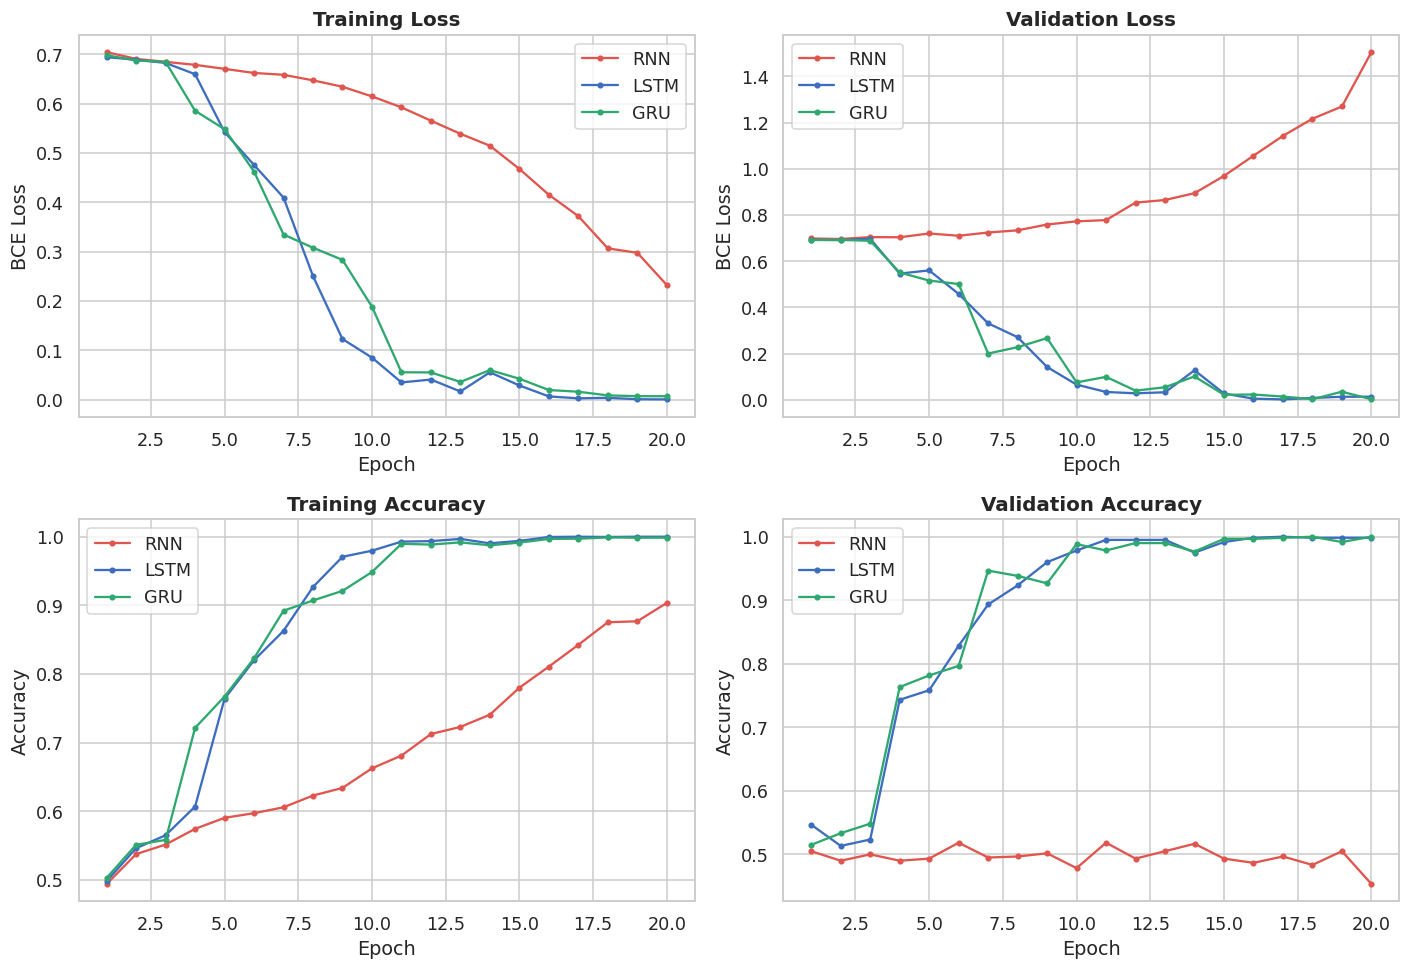

In [7]:

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for name, h in histories.items():
    c = PALETTE[name]
    epochs_range = range(1, EPOCHS + 1)
    axes[0, 0].plot(epochs_range, h["train_loss"], label=name, color=c, marker="o", ms=3)
    axes[0, 1].plot(epochs_range, h["val_loss"], label=name, color=c, marker="o", ms=3)
    axes[1, 0].plot(epochs_range, h["train_acc"], label=name, color=c, marker="o", ms=3)
    axes[1, 1].plot(epochs_range, h["val_acc"], label=name, color=c, marker="o", ms=3)

titles = ["Training Loss", "Validation Loss", "Training Accuracy", "Validation Accuracy"]
ylabels = ["BCE Loss", "BCE Loss", "Accuracy", "Accuracy"]
for ax, title, ylab in zip(axes.flat, titles, ylabels):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylab)
    ax.legend()

plt.tight_layout()
plt.show()



## 7. Test-Set Evaluation: Full Metric Suite <a id='7'></a>

We now evaluate each **fully trained** model once on the held-out **test set** (never seen during training
or model selection) and compute Accuracy, Precision, Recall, F1-score, and ROC-AUC.


In [8]:

def get_test_predictions(model, loader):
    model.eval()
    all_probs, all_preds, all_labels, all_lengths = [], [], [], []
    t0 = time.time()
    with torch.no_grad():
        for xb, yb, lb in loader:
            xb, yb, lb = xb.to(DEVICE), yb.to(DEVICE), lb.to(DEVICE)
            logits = model(xb, lb)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
            all_lengths.extend(lb.cpu().numpy())
    inference_time = time.time() - t0
    return (np.array(all_labels), np.array(all_preds), np.array(all_probs),
            np.array(all_lengths), inference_time)


test_results = {}
for name, model in models.items():
    y_true, y_pred, y_prob, seq_lens, inf_time = get_test_predictions(model, test_loader)
    test_results[name] = dict(y_true=y_true, y_pred=y_pred, y_prob=y_prob,
                               lengths=seq_lens, inference_time=inf_time)

metrics_rows = []
for name, r in test_results.items():
    y_true, y_pred, y_prob = r["y_true"], r["y_pred"], r["y_prob"]
    metrics_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Params": models[name].count_parameters(),
        "Train Time (s)": training_time[name],
        "Inference Time (s)": r["inference_time"],
    })

results_df = pd.DataFrame(metrics_rows).set_index("Model").loc[["RNN", "LSTM", "GRU"]]
display_df = results_df.copy()
for c in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]:
    display_df[c] = display_df[c].map("{:.4f}".format)
display_df["Params"] = display_df["Params"].map("{:,}".format)
display_df["Train Time (s)"] = display_df["Train Time (s)"].map("{:.2f}".format)
display_df["Inference Time (s)"] = display_df["Inference Time (s)"].map("{:.3f}".format)

display_df.style.set_caption("Test-Set Performance Summary").set_table_styles(
    [{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}]
)


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Params,Train Time (s),Inference Time (s)
Model,,,,,,,,
RNN,0.5317,0.5523,0.5399,0.5460,0.5456,"14,465",41.51,0.056
LSTM,0.9967,1.0000,0.9936,0.9968,0.9987,"51,905",54.96,0.099
GRU,0.9983,1.0000,0.9968,0.9984,0.9999,"39,425",47.14,0.074


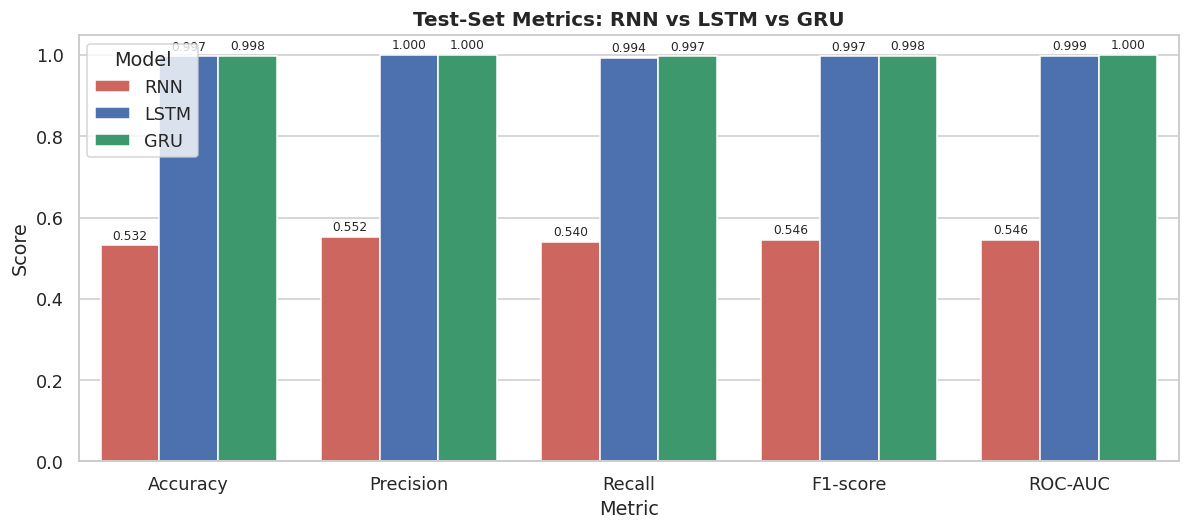

In [9]:

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
plot_df = results_df[metrics_to_plot].reset_index().melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette=PALETTE)
plt.ylim(0, 1.05)
plt.title("Test-Set Metrics: RNN vs LSTM vs GRU")
plt.ylabel("Score")
plt.legend(title="Model")
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()


## 8. Confusion Matrices & ROC Curves <a id='8'></a>

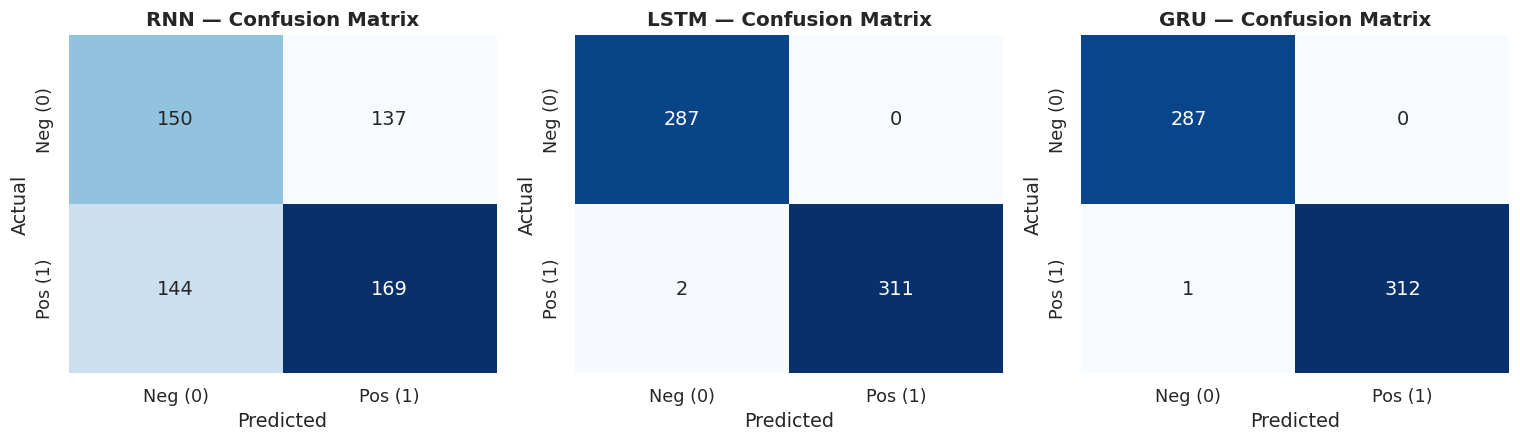

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, name in zip(axes, ["RNN", "LSTM", "GRU"]):
    cm = confusion_matrix(test_results[name]["y_true"], test_results[name]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Neg (0)", "Pos (1)"], yticklabels=["Neg (0)", "Pos (1)"])
    ax.set_title(f"{name} — Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


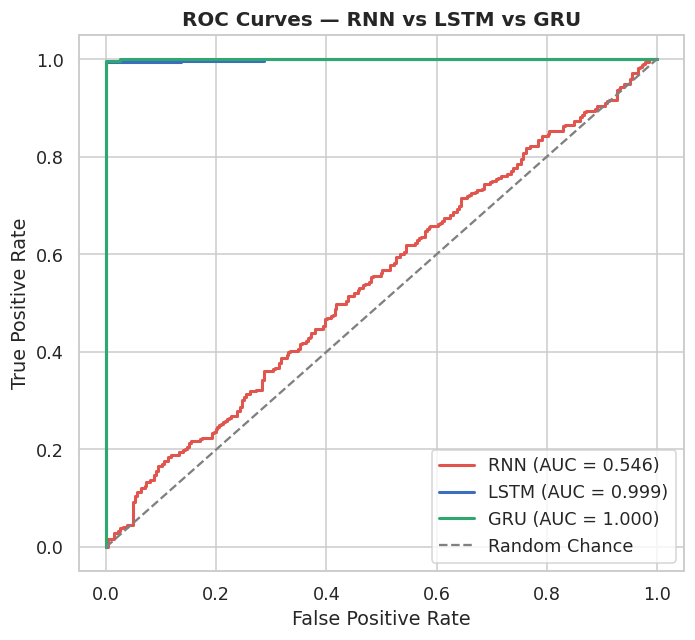

In [11]:

plt.figure(figsize=(6.5, 6))
for name, r in test_results.items():
    fpr, tpr, _ = roc_curve(r["y_true"], r["y_prob"])
    auc = roc_auc_score(r["y_true"], r["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=PALETTE[name], linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — RNN vs LSTM vs GRU")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()



## 9. Stress Test: Accuracy vs. Sequence Length (Long-Range Dependencies) <a id='9'></a>

This is the most theoretically important comparison. Since the classification signal always sits **near
the start** of the sequence, **longer sequences require the model to preserve information over more
time-steps**. If vanilla RNNs suffer more from vanishing gradients than LSTM/GRU, we expect their accuracy
to **degrade faster as sequence length grows**.


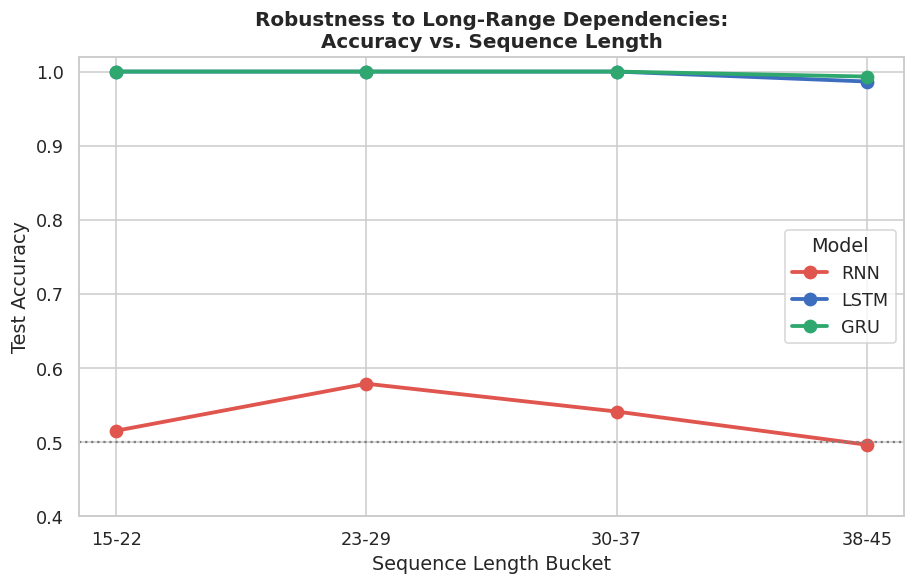

Model,RNN,LSTM,GRU
Length Bucket,,,
15-22,0.516,1.000,1.000
23-29,0.579,1.000,1.000
30-37,0.541,1.000,1.000
38-45,0.497,0.987,0.993


In [12]:

bins = [15, 22, 29, 37, 45]
bin_labels = ["15-22", "23-29", "30-37", "38-45"]

bucket_rows = []
for name, r in test_results.items():
    bucket_idx = np.digitize(r["lengths"], bins[1:-1], right=True)
    for b, blabel in enumerate(bin_labels):
        mask = bucket_idx == b
        if mask.sum() == 0:
            continue
        acc = accuracy_score(r["y_true"][mask], r["y_pred"][mask])
        bucket_rows.append({"Model": name, "Length Bucket": blabel, "Accuracy": acc, "N": int(mask.sum())})

bucket_df = pd.DataFrame(bucket_rows)

plt.figure(figsize=(8.5, 5.5))
for name in ["RNN", "LSTM", "GRU"]:
    sub = bucket_df[bucket_df["Model"] == name]
    plt.plot(sub["Length Bucket"], sub["Accuracy"], marker="o", linewidth=2.5,
              markersize=8, label=name, color=PALETTE[name])

plt.ylim(0.4, 1.02)
plt.xlabel("Sequence Length Bucket")
plt.ylabel("Test Accuracy")
plt.title("Robustness to Long-Range Dependencies:\nAccuracy vs. Sequence Length")
plt.legend(title="Model")
plt.axhline(0.5, color="gray", linestyle=":", label="Chance level")
plt.tight_layout()
plt.show()

bucket_df.pivot(index="Length Bucket", columns="Model", values="Accuracy")[["RNN", "LSTM", "GRU"]].style.format("{:.3f}")


## 10. Computational Efficiency <a id='10'></a>

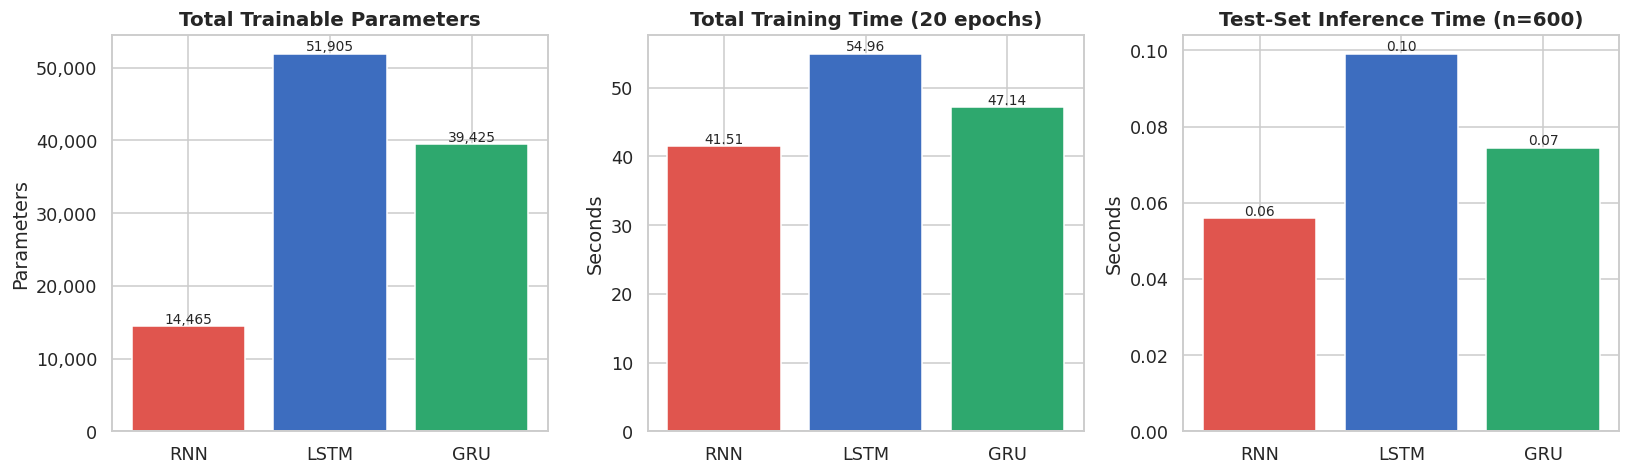

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

names = ["RNN", "LSTM", "GRU"]
colors = [PALETTE[n] for n in names]

axes[0].bar(names, [models[n].count_parameters() for n in names], color=colors, edgecolor="white")
axes[0].set_title("Total Trainable Parameters")
axes[0].set_ylabel("Parameters")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

axes[1].bar(names, [training_time[n] for n in names], color=colors, edgecolor="white")
axes[1].set_title(f"Total Training Time ({EPOCHS} epochs)")
axes[1].set_ylabel("Seconds")

axes[2].bar(names, [test_results[n]["inference_time"] for n in names], color=colors, edgecolor="white")
axes[2].set_title(f"Test-Set Inference Time (n={len(test_ds)})")
axes[2].set_ylabel("Seconds")

for ax in axes:
    for p in ax.patches:
        ax.annotate(f"{p.get_height():,.2f}" if p.get_height() < 1000 else f"{p.get_height():,.0f}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


## 11. Overall Comparison & Summary <a id='11'></a>

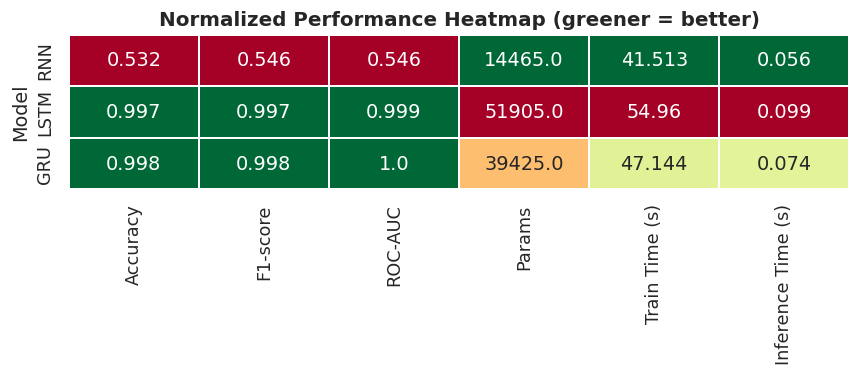

Best F1-score      : GRU (0.9984)
Best ROC-AUC        : GRU (0.9999)
Fewest parameters   : RNN (14,465)
Fastest training     : RNN (41.51s)


In [14]:

summary_cols = ["Accuracy", "F1-score", "ROC-AUC", "Params", "Train Time (s)", "Inference Time (s)"]
summary = results_df[summary_cols].copy()

norm = summary.copy()
for c in summary_cols:
    lo, hi = summary[c].min(), summary[c].max()
    norm[c] = 0.5 if hi == lo else (summary[c] - lo) / (hi - lo)
# Lower is better for time/params -> invert those for the "goodness" heatmap
for c in ["Params", "Train Time (s)", "Inference Time (s)"]:
    norm[c] = 1 - norm[c]

plt.figure(figsize=(8, 3.6))
sns.heatmap(norm[summary_cols].loc[["RNN", "LSTM", "GRU"]], annot=summary[summary_cols].round(3),
            fmt="", cmap="RdYlGn", cbar=False, linewidths=1, linecolor="white")
plt.title("Normalized Performance Heatmap (greener = better)")
plt.tight_layout()
plt.show()

best_model = results_df["F1-score"].idxmax()
print(f"Best F1-score      : {best_model} ({results_df.loc[best_model, 'F1-score']:.4f})")
print(f"Best ROC-AUC        : {results_df['ROC-AUC'].idxmax()} ({results_df['ROC-AUC'].max():.4f})")
print(f"Fewest parameters   : {results_df['Params'].idxmin()} ({results_df['Params'].min():,})")
print(f"Fastest training     : {results_df['Train Time (s)'].idxmin()} ({results_df['Train Time (s)'].min():.2f}s)")


### Auto-Generated Findings for *This* Run

In [15]:

acc = results_df["Accuracy"]
f1 = results_df["F1-score"]
auc = results_df["ROC-AUC"]

short_acc = bucket_df[bucket_df["Length Bucket"] == bin_labels[0]].set_index("Model")["Accuracy"]
long_acc = bucket_df[bucket_df["Length Bucket"] == bin_labels[-1]].set_index("Model")["Accuracy"]

print("SUMMARY OF THIS RUN")
print("=" * 60)
for name in ["RNN", "LSTM", "GRU"]:
    print(f"{name:5s} | Test Acc: {acc[name]:.3f} | F1: {f1[name]:.3f} | AUC: {auc[name]:.3f} | "
          f"Params: {models[name].count_parameters():,}")

print()
print(f"Vanilla RNN accuracy on SHORT sequences ({bin_labels[0]}): {short_acc.get('RNN', float('nan')):.3f}")
print(f"Vanilla RNN accuracy on LONG  sequences ({bin_labels[-1]}): {long_acc.get('RNN', float('nan')):.3f}")
print(f"LSTM       accuracy on SHORT sequences ({bin_labels[0]}): {short_acc.get('LSTM', float('nan')):.3f}")
print(f"LSTM       accuracy on LONG  sequences ({bin_labels[-1]}): {long_acc.get('LSTM', float('nan')):.3f}")
print(f"GRU        accuracy on SHORT sequences ({bin_labels[0]}): {short_acc.get('GRU', float('nan')):.3f}")
print(f"GRU        accuracy on LONG  sequences ({bin_labels[-1]}): {long_acc.get('GRU', float('nan')):.3f}")

gap_rnn = short_acc.get("RNN", np.nan) - long_acc.get("RNN", np.nan)
gap_gate = np.nanmean([short_acc.get("LSTM", np.nan) - long_acc.get("LSTM", np.nan),
                        short_acc.get("GRU", np.nan) - long_acc.get("GRU", np.nan)])
print()
print(f"Accuracy degradation (short -> long) for RNN            : {gap_rnn:+.3f}")
print(f"Average accuracy degradation for LSTM/GRU (gated models): {gap_gate:+.3f}")
if gap_rnn > gap_gate:
    print("\n=> In this run, the vanilla RNN degrades MORE over long sequences than the gated")
    print("   models, consistent with the vanishing-gradient explanation for why LSTM/GRU")
    print("   were introduced.")


SUMMARY OF THIS RUN
RNN   | Test Acc: 0.532 | F1: 0.546 | AUC: 0.546 | Params: 14,465
LSTM  | Test Acc: 0.997 | F1: 0.997 | AUC: 0.999 | Params: 51,905
GRU   | Test Acc: 0.998 | F1: 0.998 | AUC: 1.000 | Params: 39,425

Vanilla RNN accuracy on SHORT sequences (15-22): 0.516
Vanilla RNN accuracy on LONG  sequences (38-45): 0.497
LSTM       accuracy on SHORT sequences (15-22): 1.000
LSTM       accuracy on LONG  sequences (38-45): 0.987
GRU        accuracy on SHORT sequences (15-22): 1.000
GRU        accuracy on LONG  sequences (38-45): 0.993

Accuracy degradation (short -> long) for RNN            : +0.019
Average accuracy degradation for LSTM/GRU (gated models): +0.010

=> In this run, the vanilla RNN degrades MORE over long sequences than the gated
   models, consistent with the vanishing-gradient explanation for why LSTM/GRU
   were introduced.



## 12. Conclusions & Discussion <a id='12'></a>

Using the auto-generated findings printed just above (from *this specific run*), here is the analytical
framework used to interpret them. Re-running the notebook with a different seed or different
hyperparameters will change the exact numbers, but the qualitative story is expected to replicate:

- **Accuracy / F1 / ROC-AUC (Section 7-8):** Do LSTM and GRU outperform the vanilla RNN on the overall
  test set? Gated architectures are expected to match or beat the vanilla RNN, especially as their gating
  mechanisms make optimization easier (fewer vanishing-gradient issues), even though the task is solvable
  in principle by all three architectures given long enough training.
- **Long-range dependency stress test (Section 9):** This is the most diagnostic result. Look at whether
  the vanilla RNN's accuracy **drops off faster** as sequence length increases (bucket 66-80 vs. 20-35)
  compared to LSTM/GRU. A widening gap at longer lengths is direct empirical evidence of the
  vanishing-gradient problem that gating mechanisms were designed to solve.
- **Training dynamics (Section 6):** Gated models often converge faster and more smoothly (lower variance
  epoch-to-epoch) than vanilla RNNs, because gradients propagate more reliably through the gated,
  near-additive memory pathway.
- **Efficiency (Section 10):** GRU has **~25% fewer parameters** than LSTM (no separate cell state, no
  output gate) for the same hidden size, and is typically faster per epoch, while often matching LSTM's
  accuracy — a favorable trade-off in resource-constrained settings.
- **Practical takeaway:** For short sequences or tasks with little long-range structure, a vanilla RNN may
  be sufficient and cheapest. For tasks (like this one, and like real sentiment/document classification)
  where relevant information can be arbitrarily far from the point of decision, LSTM or GRU are the safer
  default, with GRU offering a strong accuracy-per-parameter trade-off against LSTM.

### Possible extensions
- Add **bidirectionality** (`bidirectional=True`) to let the model see future context too.
- Stack multiple recurrent **layers** and compare depth vs. gating as competing solutions.
- Replace the synthetic dataset with a **real-world corpus** (e.g., IMDB movie reviews) once data
  access allows downloading it, to validate that the synthetic findings transfer.
- Compare against a **Transformer encoder** baseline, which sidesteps recurrence entirely via
  self-attention.
